## 🌡️ Thailand Temperature Forecasting: Prophet Analysis

---
**📌 Project Overview**: This project aims to analyze and forecast average temperatures in Thailand. It uses NASA data from 2022 to 2025 to identify trends and seasonal patterns. The goal is to create a high-accuracy model to predict temperatures for the next 12 months.

---
**📚 Data Source**: Thailand Weather 2022 - 2025 >> https://www.kaggle.com/datasets/sakdaphoda/thai-weather-2022-2025/data?select=Thailand_Weather_NASA_2022_2025.csv

# Setup Environment

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter as kda
from sklearn.metrics import mean_absolute_percentage_error
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

import warnings 
warnings.filterwarnings('ignore')


In [4]:
df = kagglehub.dataset_load(kda.PANDAS, 'sakdaphoda/thai-weather-2022-2025','Thailand_Weather_NASA_2022_2025.csv')
df = df[['Date','Mean_Temp']]
df.columns = df.columns.str.lower().str.strip()
df['date'] = pd.to_datetime(df['date'])
df = df.rename(columns={'mean_temp':'temp'})
df = df.set_index('date')
df.head()


,temp
date,
2022-01-01,24.37
2022-01-02,24.42
2022-01-03,25.10
2022-01-04,26.02
2022-01-05,25.99


In [5]:
df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 1461 entries, 2022-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    1461 non-null   float64
dtypes: float64(1)
memory usage: 22.8 KB


In [6]:
print(f'number of null >> {df.isna().sum()} row')


number of null >> temp    0
dtype: int64 row


In [7]:
df.describe()


,temp
count,1461.000000
mean,28.172902
std,2.523200
min,18.310000
25%,26.860000
50%,28.180000
75%,29.450000
max,36.030000


# Check Skewness

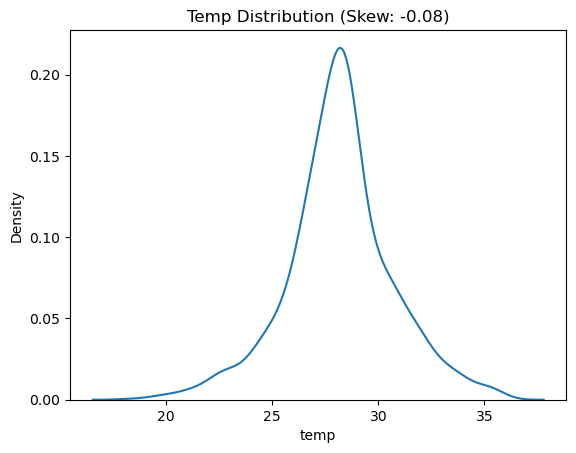

In [4]:
sns.kdeplot(df['temp'])
plt.title(f'Temp Distribution (Skew: {df.temp.skew():.2f})')
plt.show()


- The data is already normal, so we don't need to fix the distribution.

# Split Train and Test

In [8]:
test_start = '2025-01-01'
train = df.loc[df.index < test_start].copy() # 2022-01-01 to 2024-12-31
test = df.loc[df.index >= test_start].copy() # 2025-01-01 to 2025-12-31


# Prediction

## Predict by Baseline Model

17:42:08 - cmdstanpy - INFO - Chain [1] start processing
17:42:08 - cmdstanpy - INFO - Chain [1] done processing


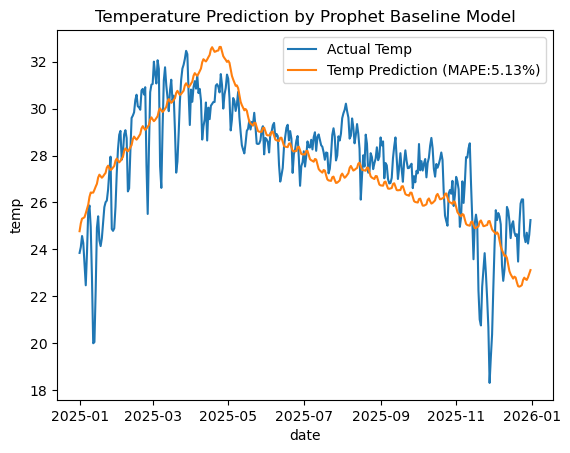

In [9]:
train_prophet = train.reset_index().rename(columns={'date':'ds','temp':'y'})
test_prophet = test.reset_index()[['date']].rename(columns={'date':'ds'})

p_model = Prophet(yearly_seasonality=True)
p_model.fit(train_prophet)
y_temp = p_model.predict(test_prophet)
test['temp_pred'] = y_temp.set_index('ds')['yhat']

sns.lineplot(test, x=test.index, y='temp', label='Actual Temp')
sns.lineplot(test, x=test.index, y='temp_pred', label=f'Temp Prediction (MAPE:{mean_absolute_percentage_error(test.temp, test.temp_pred):.2%})')
plt.title('Temperature Prediction by Prophet Baseline Model')
plt.show()


## Tuning Model by Optuna

In [12]:
error_list_trend = []

def objective(trial):
    param = {
    'changepoint_prior_scale':trial.suggest_float('changepoint_prior_scale',0.1, 1)
    , 'changepoint_range':trial.suggest_float('changepoint_range',0.1, 0.9)
    , 'seasonality_prior_scale':trial.suggest_float('seasonality_prior_scale',0.1, 15)
    }
    
    m = Prophet(**param, yearly_seasonality=True)
    m.fit(train_prophet)

    cv = cross_validation(
        m
        , initial= f'{365*2} days'
        , horizon= '180 days'
        , period= '30 days'
        , parallel='processes'
    )
    
    error = performance_metrics(cv, rolling_window=1)
    mape = error['mape'].values[0]

    return mape

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print('Best Params:', study.best_params)
print('Best MAPE:', study.best_value)


Best Params: {'changepoint_prior_scale': 0.667557544167733, 'changepoint_range': 0.21100954626119894, 'seasonality_prior_scale': 10.804481170276174}
Best MAPE: 0.051459601382122126


## Predict by Tuning Model

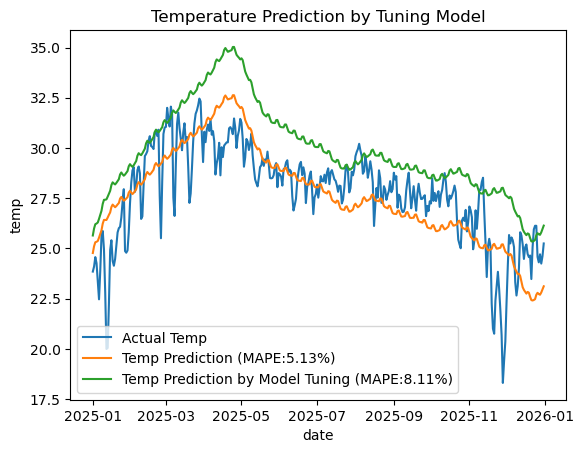

In [61]:
p_model_tuning = Prophet(
    yearly_seasonality=True
    , **study.best_params
).fit(train_prophet)
y_trend_tuning = p_model_tuning.predict(test_prophet)
test['temp_pred_tuning'] = y_trend_tuning.set_index('ds')['yhat']

sns.lineplot(test, x=test.index, y='temp', label='Actual Temp')
sns.lineplot(test, x=test.index, y='temp_pred', label=f'Temp Prediction (MAPE:{mean_absolute_percentage_error(test.temp, test.temp_pred):.2%})')
sns.lineplot(test, x=test.index, y='temp_pred_tuning', label=f'Temp Prediction by Model Tuning (MAPE:{mean_absolute_percentage_error(test.temp, test.temp_pred_tuning):.2%})')
plt.title('Temperature Prediction by Tuning Model')
plt.show()


By comparing the MAPE (Mean Absolute Percentage Error), I found that the Baseline Model has a lower error rate than the Tuned Model. Therefore, I have decided to use the Baseline Model for temperature forecasting. It provides the most accurate results and is more stable for real-world use.

# Predict Next 12 Months

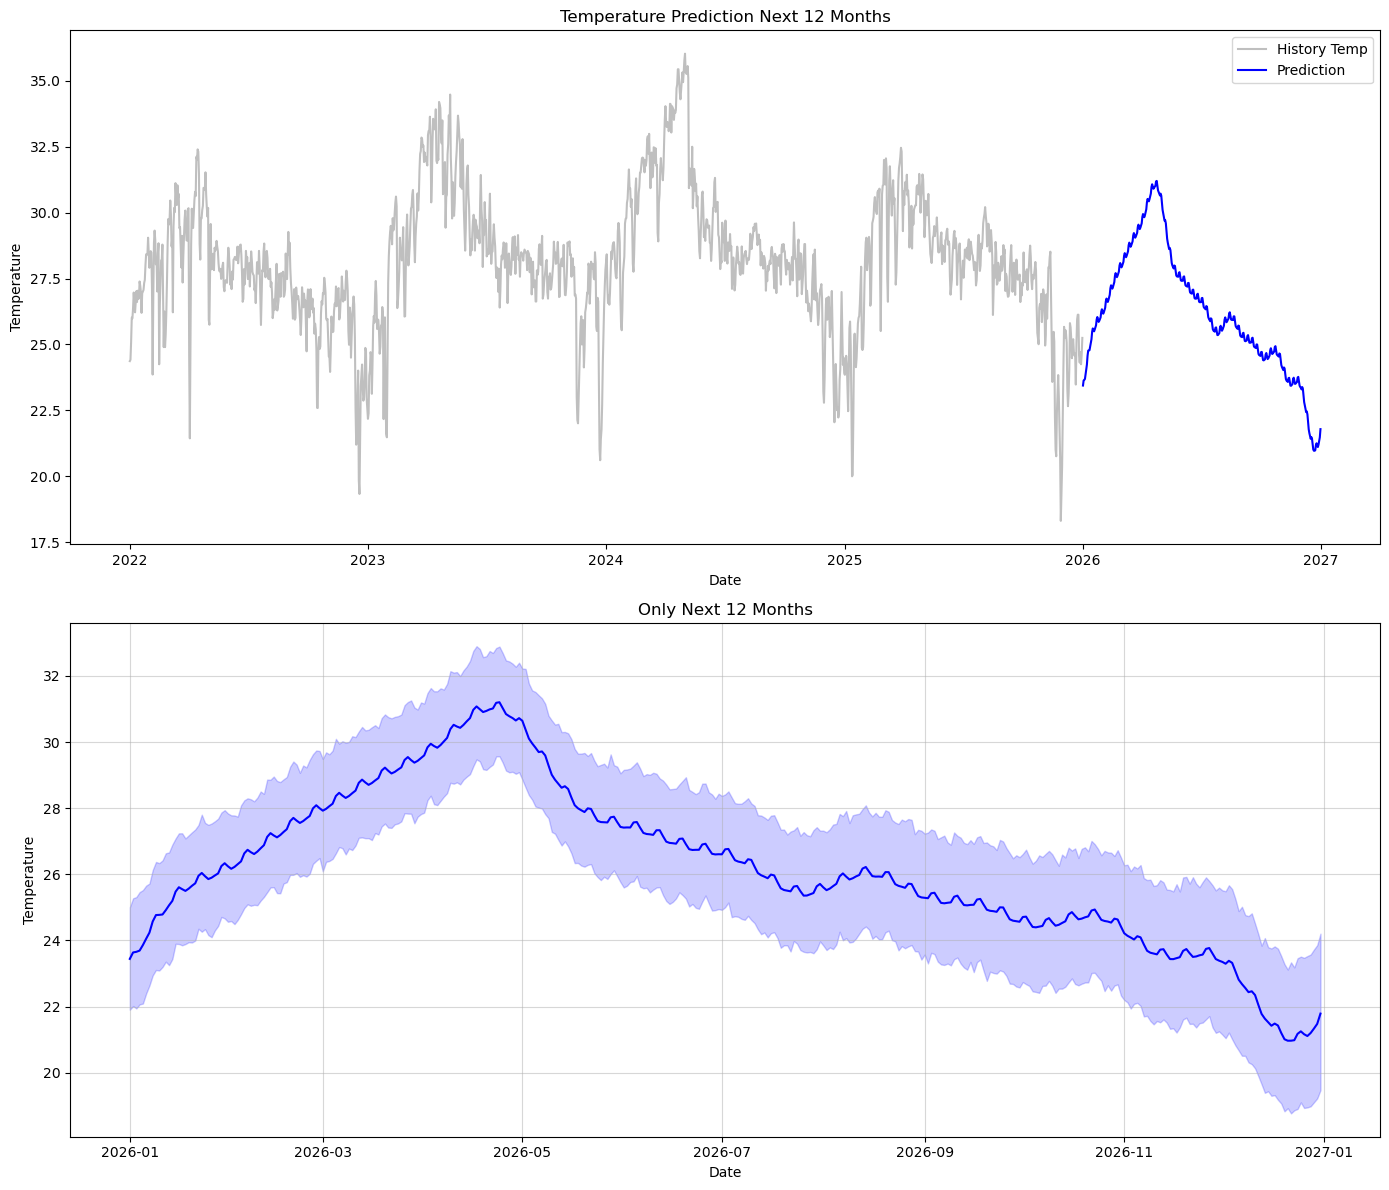

In [68]:
next_6m = pd.date_range(
    start=test.index.max() + pd.Timedelta(days=1)
    , end=test.index.max() + pd.offsets.MonthEnd(12)
    , freq='D'
)
next_6m = pd.DataFrame(next_6m, columns=['ds'])

y_temp_next = p_model.predict(next_6m)

next_6m= y_temp_next.set_index('ds')[['yhat','yhat_lower','yhat_upper']]

fig, ax = plt.subplots(2,1,figsize=(14,12))
sns.lineplot(df, x=df.index, y='temp', color='gray', alpha=0.5, label='History Temp', ax=ax[0])
sns.lineplot(next_6m, x=next_6m.index, y='yhat', color='blue', label='Prediction', ax=ax[0])
ax[0].set_title('Temperature Prediction Next 12 Months')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Temperature')

sns.lineplot(next_6m, x=next_6m.index, y='yhat', color='blue', ax=ax[1])
plt.fill_between(
    next_6m.index
    , next_6m['yhat_lower']
    , next_6m['yhat_upper']
    , color='blue'
    , alpha=0.2
)
ax[1].set_title('Only Next 12 Months')
ax[1].grid(alpha=0.5)
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Temperature')

plt.tight_layout()
plt.show()


# Model Explaination

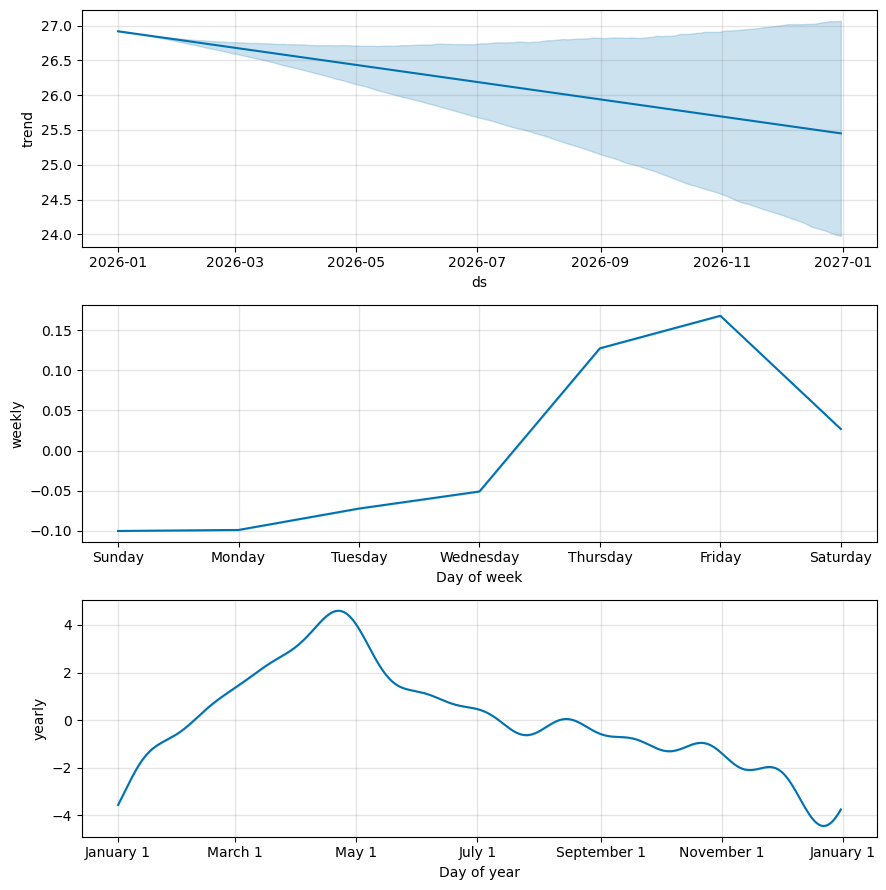

In [72]:
p_model.plot_components(y_temp_next)
plt.show()


- **Main Trend**: The data shows a steady "downward trend" throughout 2026, dropping from about 27.0 to 25.5.
- **Weekly Patterns**: The values tend to be higher on Thursdays and Fridays. On the other hand, Sunday through Wednesday usually see slightly lower values than average.
- **Yearly Patterns**: This has the biggest impact on the data. Values peak in May and hit their lowest point at the turn of the year (December/January).